In [4]:
!pip install tensorflow

  Using cached tensorflow-2.20.0-cp313-cp313-win_amd64.whl.metadata (4.6 kB)
Using cached tensorflow-2.20.0-cp313-cp313-win_amd64.whl (332.0 MB)


ERROR: Could not install packages due to an OSError: [WinError 32] The process cannot access the file because it is being used by another process: 'C:\\Users\\vemyl\\anaconda3\\Lib\\site-packages\\tensorflow\\python\\_pywrap_tensorflow_common.dll'
Consider using the `--user` option or check the permissions.



In [5]:
# ===========================================
# 1. Imports
# ===========================================
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from itertools import cycle

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix


os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

In [6]:

train_dir = r"dataset/data3a/training"
val_dir = r"dataset/data3a/validation"


BATCH_SIZE = 32
IMG_SIZE = (224, 224)
EPOCHS = 100

In [7]:

train_datagen = ImageDataGenerator(rescale=1./255,
                                   rotation_range=40,
                                   width_shift_range=0.2,
                                   height_shift_range=0.2,
                                   zoom_range=0.3,
                                   shear_range=0.2,
                                   horizontal_flip=True,
                                   brightness_range=[0.8, 1.2])

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(train_dir,
                                                    target_size=IMG_SIZE,
                                                    batch_size=BATCH_SIZE,
                                                    class_mode='categorical',
                                                    shuffle=True)

val_generator = val_datagen.flow_from_directory(val_dir,
                                                target_size=IMG_SIZE,
                                                batch_size=BATCH_SIZE,
                                                class_mode='categorical',
                                                shuffle=False)

class_names = list(train_generator.class_indices.keys())
print("Classes:", class_names)

Found 1383 images belonging to 3 classes.
Found 248 images belonging to 3 classes.
Classes: ['01-minor', '02-moderate', '03-severe']


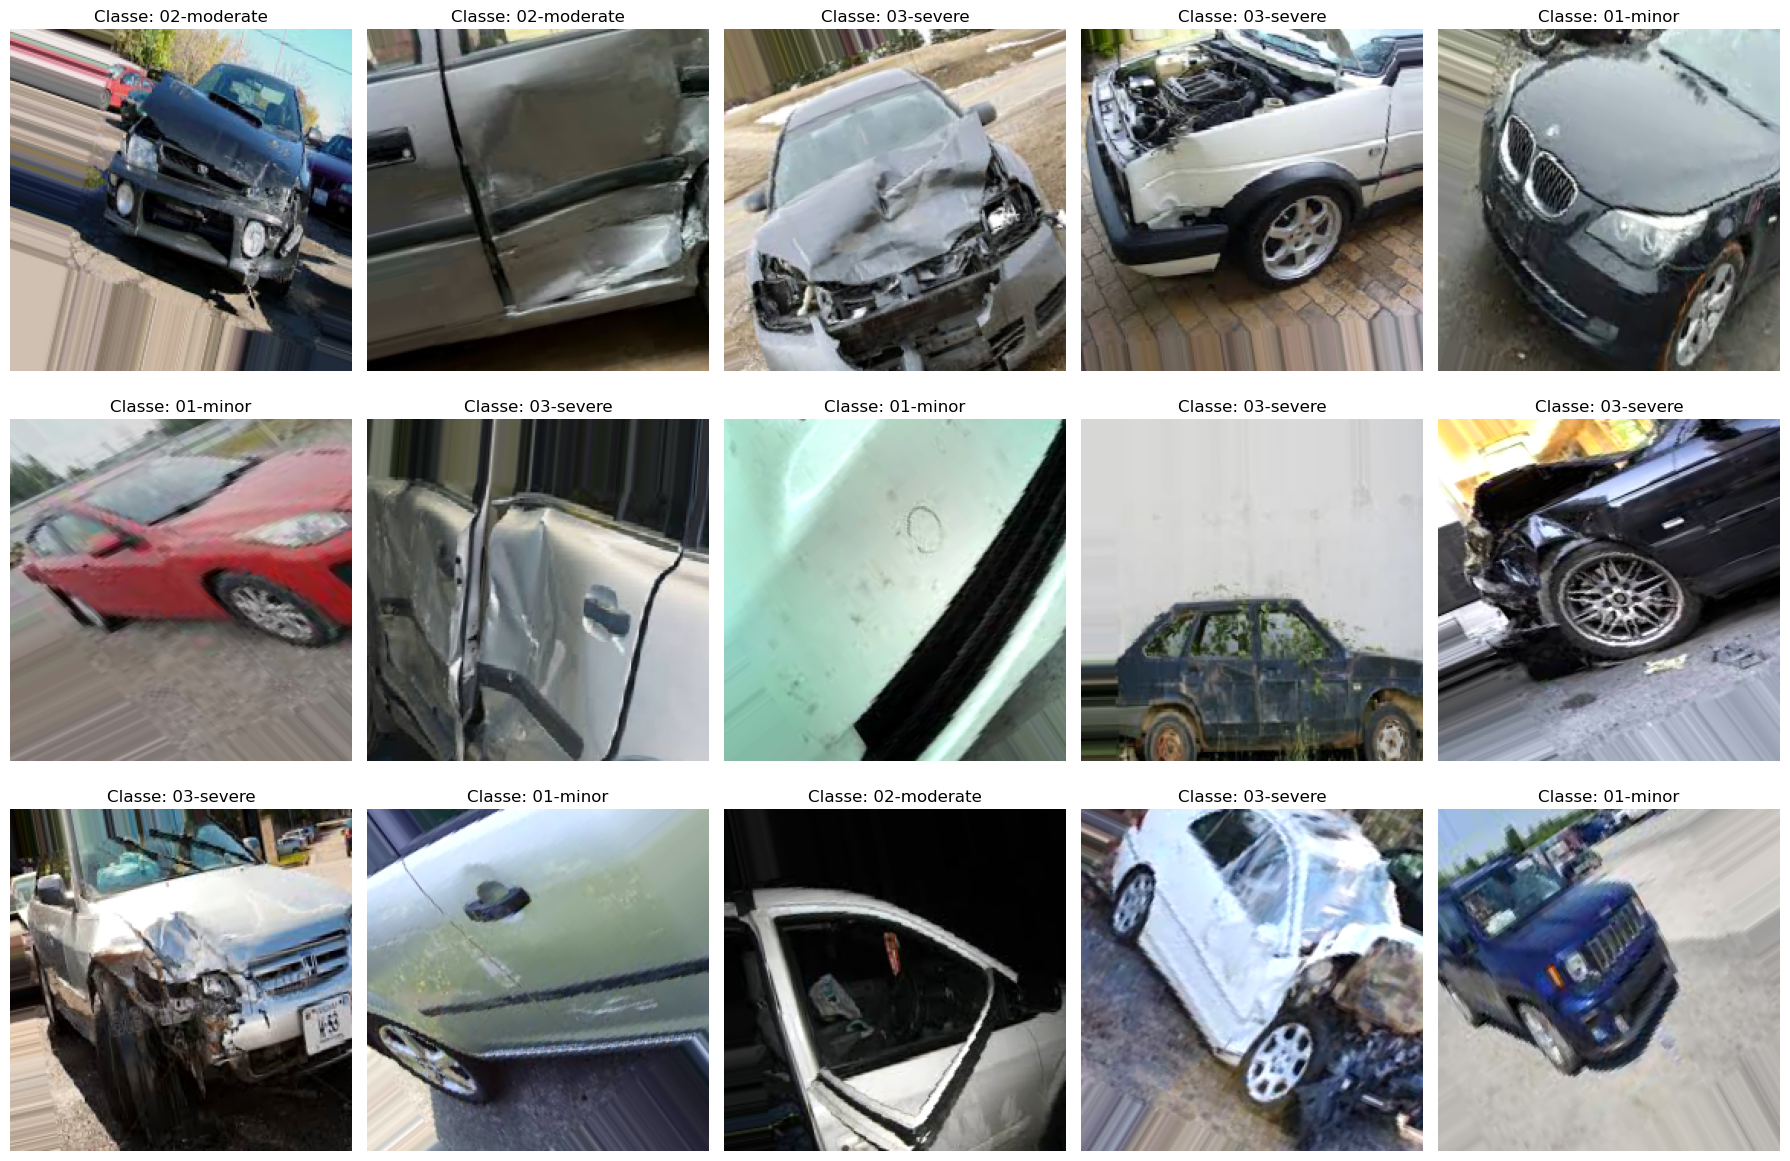

In [8]:

def show_augmented_images(generator, class_names, n_images=15):
    images, labels = next(generator)  
    plt.figure(figsize=(18, 12))
    for i in range(n_images):
        plt.subplot(3, 5, i + 1)
        plt.imshow(images[i])
        plt.axis('off')
        class_index = np.argmax(labels[i])
        plt.title(f"Classe: {class_names[class_index]}")
    plt.tight_layout()
    plt.show()


show_augmented_images(train_generator, class_names, n_images=15)


# Convolutional neural network 1

In [9]:
# ===========================================
# 5. Class Weights
# ===========================================
y_train = train_generator.classes
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(class_weights))


In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, Flatten, BatchNormalization

# ===========================================
# 6. CNN Customizada
# ===========================================
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    
    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    
    Conv2D(256, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# ===========================================
# 7. Callbacks
# ===========================================
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ModelCheckpoint('cnn_custom_best.h5', save_best_only=True)
]

model.summary()


C:\Users\vemyl\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 222, 222, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 109, 109, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 52, 52, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 24, 24, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 24, 24, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 12, 12, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 36864)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │      18,874,880 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          65,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 19,331,267 (73.74 MB)

 Trainable params: 19,330,307 (73.74 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:

history = model.fit(train_generator,
                    validation_data=val_generator,
                    epochs=EPOCHS)

Epoch 1/100
12/44 ━━━━━━━━━━━━━━━━━━━━ 2:47 5s/step - accuracy: 0.3766 - loss: 2.8010

In [ ]:

def plot_history(history):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Val')
    plt.title("Accuracy")
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Val')
    plt.title("Loss")
    plt.legend()
    plt.show()

plot_history(history)

In [ ]:

val_generator.reset()
y_true = val_generator.classes
y_pred_probs = model.predict(val_generator)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

In [ ]:

y_true_bin = label_binarize(y_true, classes=[0, 1, 2])  # 3 classes


fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])


colors = cycle(['darkorange', 'green', 'blue'])
plt.figure(figsize=(8, 6))

for i, color in zip(range(3), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'Classe {class_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curvas ROC por Classe (CNN Customizada)')
plt.legend(loc="lower right")
plt.grid()
plt.show()

In [ ]:
print("Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=class_names))

In [ ]:

cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# ===========================================
# 10. ROC Curve
# ===========================================
y_true_bin = label_binarize(y_true, classes=[0, 1, 2])
fpr, tpr, roc_auc = {}, {}, {}
for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

colors = cycle(['darkorange', 'green', 'blue'])
plt.figure(figsize=(8, 6))
for i, color in zip(range(3), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'Classe {class_names[i]} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('Curvas ROC por Classe (CNN Customizada)')
plt.legend(loc="lower right")
plt.grid()
plt.show()

In [ ]:

filepaths = [os.path.join(val_dir, fname) for fname in val_generator.filenames]


def show_predictions(filepaths, y_true, y_pred, class_names, n=15):
    plt.figure(figsize=(18, 12))
    for i in range(n):
        img = tf.keras.preprocessing.image.load_img(filepaths[i], target_size=IMG_SIZE)
        plt.subplot(3, 5, i + 1)
        plt.imshow(img)
        plt.axis('off')
        true_label = class_names[y_true[i]]
        pred_label = class_names[y_pred[i]]
        color = 'green' if true_label == pred_label else 'red'
        plt.title(f'True: {true_label}\nPred: {pred_label}', color=color)
    plt.tight_layout()
    plt.show()


print("\nCNN:")
show_predictions(filepaths, y_true, y_pred_classes, class_names, n=15)


wrong_indices = np.where(y_true != y_pred_classes)[0]
if len(wrong_indices) > 0:
    print(f"\n 15 paths :")
    show_predictions([filepaths[i] for i in wrong_indices],
                     [y_true[i] for i in wrong_indices],
                     [y_pred_classes[i] for i in wrong_indices],
                     class_names, n=min(15, len(wrong_indices)))
else:
    print("")

# Convolutional neural network 2 - MobileNetV2

In [ ]:
# ===========================================
# 5. Class Weights
# ===========================================
y_train = train_generator.classes
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = dict(enumerate(class_weights))
print("Pesos das classes:", class_weights_dict)

In [ ]:
# ===========================================
# 6. Modelo MobileNetV2 and Fine-Tuning
# ===========================================
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))


base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False


x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
output = Dense(3, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# ===============================
# 6. Callbacks
# ===============================
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ModelCheckpoint('mobilenetv2_best.h5', save_best_only=True)
]

#
model.summary()

In [ ]:

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS)

In [ ]:

def plot_training_history(history):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Validation')
    plt.title('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Validation')
    plt.title('Loss')
    plt.legend()

    plt.show()

plot_training_history(history)

In [ ]:

val_generator.reset()
y_true = val_generator.classes
y_pred = model.predict(val_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

In [ ]:

print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes, target_names=class_names))

In [ ]:

n_classes = len(class_names)


y_true_bin = label_binarize(y_true, classes=[0, 1, 2])  # classes [0, 1, 2]

# Curvas ROC
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

colors = cycle(['darkorange', 'green', 'blue'])

# Plot
plt.figure(figsize=(8, 6))
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'Classe {class_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curvas ROC por Classe')
plt.legend(loc="lower right")
plt.grid()
plt.show()


In [ ]:

cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:

val_generator.reset()


y_pred_probs = model.predict(val_generator)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true = val_generator.classes
class_names = list(val_generator.class_indices.keys())


filenames = val_generator.filenames
filepaths = [os.path.join(val_dir, f) for f in filenames]


def show_predictions(filepaths, y_true, y_pred, class_names, n=15):
    plt.figure(figsize=(18, 12))
    for i in range(n):
        img = tf.keras.preprocessing.image.load_img(filepaths[i], target_size=IMG_SIZE)
        plt.subplot(3, 5, i + 1)
        plt.imshow(img)
        plt.axis('off')
        true_label = class_names[y_true[i]]
        pred_label = class_names[y_pred[i]]
        color = 'green' if true_label == pred_label else 'red'
        plt.title(f'True: {true_label}\nPred: {pred_label}', color=color)
    plt.tight_layout()
    plt.show()

In [ ]:

show_predictions(filepaths, y_true, y_pred_classes, class_names, n=15)

In [ ]:

wrong_indices = np.where(y_true != y_pred_classes)[0]


show_predictions([filepaths[i] for i in wrong_indices],
                 [y_true[i] for i in wrong_indices],
                 [y_pred_classes[i] for i in wrong_indices],
                 class_names, 
                 n=15)


# Convolutional neural network 3 - VGG16

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16

# ===========================================
# 6. Modelo VGG16 +  Topo
# ===========================================
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = True
for layer in base_model.layers[:-8]:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
output = Dense(3, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])


callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ModelCheckpoint('vgg16_best.h5', save_best_only=True)
]

#
model.summary()

In [ ]:

history = model.fit(train_generator,
                    validation_data=val_generator,
                    epochs=EPOCHS)

In [ ]:

def plot_history(history):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Val')
    plt.title("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Val')
    plt.title("Loss")
    plt.legend()

    plt.show()

plot_history(history)

In [ ]:

val_generator.reset()
y_true = val_generator.classes
y_pred_probs = model.predict(val_generator)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

In [ ]:
# Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=class_names))

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:

y_true_bin = label_binarize(y_true, classes=[0, 1, 2])
fpr, tpr, roc_auc = {}, {}, {}

for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

colors = cycle(['darkorange', 'green', 'blue'])
plt.figure(figsize=(8, 6))

for i, color in zip(range(3), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'Classe {class_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curvas ROC por Classe (VGG16)')
plt.legend(loc="lower right")
plt.grid(False)
plt.show()

In [ ]:

filepaths = [os.path.join(val_dir, fname) for fname in val_generator.filenames]


def show_predictions(filepaths, y_true, y_pred, class_names, n=15):
    plt.figure(figsize=(18, 12))
    for i in range(n):
        img = tf.keras.preprocessing.image.load_img(filepaths[i], target_size=IMG_SIZE)
        plt.subplot(3, 5, i + 1)
        plt.imshow(img)
        plt.axis('off')
        true_label = class_names[y_true[i]]
        pred_label = class_names[y_pred[i]]
        color = 'green' if true_label == pred_label else 'red'
        plt.title(f'True: {true_label}\nPred: {pred_label}', color=color)
    plt.tight_layout()
    plt.show()

# Previsões aleatórias
print("\n search:")
show_predictions(filepaths, y_true, y_pred_classes, class_names, n=15)

# Mostrar apenas os erros
wrong_indices = np.where(y_true != y_pred_classes)[0]
if len(wrong_indices) > 0:
    print(f"\n 15 images:")
    show_predictions([filepaths[i] for i in wrong_indices],
                     [y_true[i] for i in wrong_indices],
                     [y_pred_classes[i] for i in wrong_indices],
                     class_names, n=min(15, len(wrong_indices)))
else:
    print("true predictions")


# Modelo 4 - Yolo Reconhecimento

In [ ]:
!pip install ultralytics

In [ ]:
import os
import shutil
from PIL import Image
from tqdm import tqdm
from ultralytics import YOLO

In [ ]:
# Diretórios de entrada
source_root = r"dataset/data3a"
target_root = r"results (1)/car_damage_yolo/data.yaml"

# Mapeamento de classes
class_mapping = {
    "01-minor": 0,
    "02-moderate": 1,
    "03-severe": 2
}

# Criação da estrutura YOLO (images/ e labels/)
for split in ["train", "val"]:
    os.makedirs(f"{target_root}/images/{split}", exist_ok=True)
    os.makedirs(f"{target_root}/labels/{split}", exist_ok=True)

    for class_folder in class_mapping.keys():
        class_id = class_mapping[class_folder]
        img_dir = os.path.join(source_root, "training" if split=="train" else "validation", class_folder)
        img_files = [f for f in os.listdir(img_dir) if f.lower().endswith((".jpg", ".jpeg", ".png"))]

        for img_file in tqdm(img_files, desc=f"{split} - {class_folder}"):
            src_img = os.path.join(img_dir, img_file)
            dst_img = os.path.join(f"{target_root}/images/{split}", img_file)
            dst_txt = os.path.join(f"{target_root}/labels/{split}", img_file.rsplit(".", 1)[0] + ".txt")

            # Copia imagem
            shutil.copyfile(src_img, dst_img)

            # Cria bounding box central (falsa)
            with Image.open(src_img) as im:
                w, h = im.size
            x_center, y_center = 0.5, 0.5
            box_width, box_height = 0.8, 0.8

            with open(dst_txt, "w") as f:
                f.write(f"{class_id} {x_center} {y_center} {box_width} {box_height}\n")

In [ ]:
data_yaml = """
path: /kaggle/working/car_damage_yolo
train: images/train
val: images/val

names:
  0: minor
  1: moderate
  2: severe
"""

with open(r"results (1)/car_damage_yolo/data.yaml", "w") as f:
    f.write(data_yaml)


In [ ]:
# Modelo yolo
model = YOLO("yolov8n.pt")  # ou yolov8s.pt para versão mais robusta

In [ ]:
# Treinamento modelo
model.train(data=r"results (1)/car_damage_yolo/data.yaml",
            epochs=100,
            imgsz=640,
            batch=16,
            name="car_damage_detector")

In [ ]:

model = YOLO(r"results (1)/runs/detect/car_damage_detector/weights/best.pt")

results = model.predict(source=r"results (1)/car_damage_yolo/images/val", 
                        conf=0.10,
                        save=True)

In [ ]:
from IPython.display import Image, display
import glob

predicted_images = glob.glob(r"results (1)/runs/detect/predict/*.jpg")

for img_path in predicted_images[:30]:
    display(Image(filename=img_path))

In [ ]:
from ultralytics import YOLO
from PIL import Image
from IPython.display import display
from glob import glob
import os

img_paths = [
    r"dataset/data3a/validation/01-minor/0004.JPEG",
    r"dataset/data3a/validation/02-moderate/0015.jpeg",
    r"dataset/data3a/validation/03-severe/0028.JPEG"
]


model = YOLO(r"results (1)/runs/detect/car_damage_detector/weights/best.pt")

In [ ]:

for img_path in img_paths:
    print(f"input image: {img_path}")
    
    results = model.predict(source=img_path, conf=0.4, save=True)

   
    saved_imgs = glob(f"{results[0].save_dir}/*.jpg") + \
                 glob(f"{results[0].save_dir}/*.jpeg") + \
                 glob(f"{results[0].save_dir}/*.png")
    
    if saved_imgs:
        display(Image.open(saved_imgs[-1]))  
    else:
        print("")